<a href="https://colab.research.google.com/github/mu1322/kaggle_workplace/blob/main/pytorch_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


画像データの読み込み

In [4]:
import pathlib
imgdir_path = pathlib.Path('/content/drive/MyDrive/Colab Notebooks/pytorch_study/machine-learning-book-main/ch12/cat_dog_images')
file_list = sorted([str(path) for path in imgdir_path.glob('*.jpg')])
print(file_list)

['/content/drive/MyDrive/Colab Notebooks/pytorch_study/machine-learning-book-main/ch12/cat_dog_images/cat-01.jpg', '/content/drive/MyDrive/Colab Notebooks/pytorch_study/machine-learning-book-main/ch12/cat_dog_images/cat-02.jpg', '/content/drive/MyDrive/Colab Notebooks/pytorch_study/machine-learning-book-main/ch12/cat_dog_images/cat-03.jpg', '/content/drive/MyDrive/Colab Notebooks/pytorch_study/machine-learning-book-main/ch12/cat_dog_images/dog-01.jpg', '/content/drive/MyDrive/Colab Notebooks/pytorch_study/machine-learning-book-main/ch12/cat_dog_images/dog-02.jpg', '/content/drive/MyDrive/Colab Notebooks/pytorch_study/machine-learning-book-main/ch12/cat_dog_images/dog-03.jpg']


可視化

Image shape: (900, 1200, 3)
Image shape: (900, 1200, 3)
Image shape: (900, 742, 3)
Image shape: (800, 1200, 3)
Image shape: (800, 1200, 3)
Image shape: (900, 1200, 3)


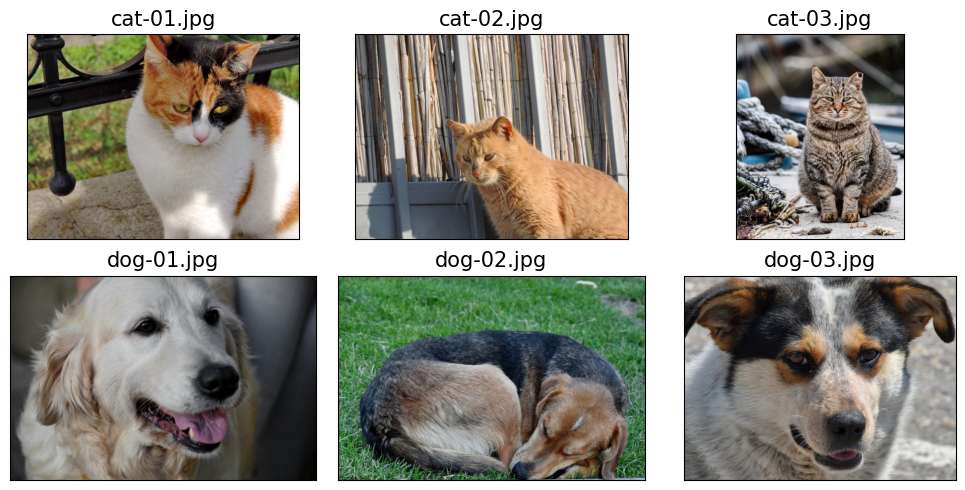

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import os
from PIL import Image
fig = plt.figure(figsize=(10, 5))
for i, file in enumerate(file_list):
  img = Image.open(file)
  print('Image shape:', np.array(img).shape)
  ax = fig.add_subplot(2, 3, i+1)
  ax.set_xticks([]); ax.set_yticks([])
  ax.imshow(img)
  ax.set_title(os.path.basename(file), size=15)

plt.tight_layout()
plt.show()

In [8]:
labels = [1 if 'dog' in os.path.basename(file) else 0 for file in file_list]
print(labels)

[0, 0, 0, 1, 1, 1]


In [12]:
from torch.utils.data import Dataset

class ImageDataset(Dataset):
  def __init__(self, file_name, labels):
    self.file_name = file_name
    self.labels = labels

  def __getitem__(self, index):
    file = self.file_name[index]
    label = self.labels[index]
    return file, label

  def __len__(self):
    return len(self.labels)

image_dataset = ImageDataset(file_list, labels)
for file, label in image_dataset:
  print(file, label)

/content/drive/MyDrive/Colab Notebooks/pytorch_study/machine-learning-book-main/ch12/cat_dog_images/cat-01.jpg 0
/content/drive/MyDrive/Colab Notebooks/pytorch_study/machine-learning-book-main/ch12/cat_dog_images/cat-02.jpg 0
/content/drive/MyDrive/Colab Notebooks/pytorch_study/machine-learning-book-main/ch12/cat_dog_images/cat-03.jpg 0
/content/drive/MyDrive/Colab Notebooks/pytorch_study/machine-learning-book-main/ch12/cat_dog_images/dog-01.jpg 1
/content/drive/MyDrive/Colab Notebooks/pytorch_study/machine-learning-book-main/ch12/cat_dog_images/dog-02.jpg 1
/content/drive/MyDrive/Colab Notebooks/pytorch_study/machine-learning-book-main/ch12/cat_dog_images/dog-03.jpg 1


画像サイズの変更、統一

In [15]:
import torchvision.transforms as transforms
img_height, img_width = 80, 120
transform = transforms.Compose([transforms.ToTensor(), transforms.Resize((img_height, img_width))])

In [16]:
print(transform)

Compose(
    ToTensor()
    Resize(size=(80, 120), interpolation=bilinear, max_size=None, antialias=True)
)


トランスフォームを含めた　データの読み込み

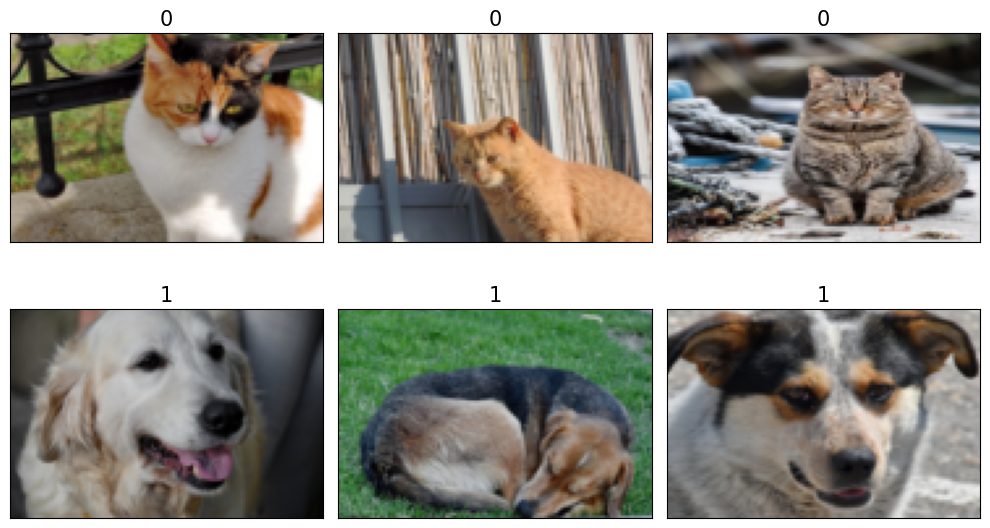

In [24]:
class ImageDataset(Dataset):
  def __init__(self, file_list, labels, transform=None):
    self.file_list = file_list
    self.labels = labels
    self.transform = transform

  def __getitem__(self, index):
    img = Image.open(self.file_list[index])
    if self.transform != None:
      img = transform(img)
    label = self.labels[index]
    return img, label

  def __len__(self):
    return len(self.labels)

image_dataset = ImageDataset(file_list, labels, transform)

fig = plt.figure(figsize=(10, 6))
for i, example in enumerate(image_dataset, 0):
  ax = fig.add_subplot(2, 3, i+1)
  ax.set_xticks([]); ax.set_yticks([])
  ax.imshow(example[0].numpy().transpose((1, 2, 0)))
  ax.set_title(f'{example[1]}', size=15)

plt.tight_layout()
plt.show()